<a href="https://colab.research.google.com/github/AmirMahdiRezaeiEECS/Auto-Labeler-YOLO-format-/blob/main/car_auto_label_yolo-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# High-Accuracy Car Bounding-Box Auto-Labeler (YOLO format)

**Goal**: Auto-generate YOLO-format bounding boxes for ~1 500 already-classified car images  
**Model**: Ultralytics **YOLO26x** (strongest practical free-GPU detector, COCO-pretrained)  
**Priority**: Accuracy ≫ speed  
**Output**: `labels/*.txt` (class_id xc yc w h) + optional visualizations + ready-to-train `dataset.yaml`

### Expected folder layout (choose one)
```
data/
├── class_0/          # or sedan/, suv/, truck/ …
│   ├── img001.jpg
│   └── …
├── class_1/
│   └── …
└── …
```
or a flat folder + a mapping CSV/JSON (see config cell).

Run all cells top-to-bottom on a free T4 (Colab) or P100/T4 (Kaggle).

## 1. Environment & GPU check

In [1]:
# Install / upgrade (quiet)
!pip install -q -U ultralytics opencv-python-headless pillow tqdm pyyaml

import torch, ultralytics, platform, os, sys
print(f"Python        : {sys.version.split()[0]}")
print(f"Platform      : {platform.platform()}")
print(f"Ultralytics   : {ultralytics.__version__}")
print(f"Torch         : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  No GPU detected – inference will be extremely slow. Switch runtime to GPU!")

Python        : 3.13.15
Platform      : Linux-6.6.122+-x86_64-with-glibc2.39
Ultralytics   : 8.4.160
Torch         : 2.11.0+cu128
CUDA available: True
GPU           : Tesla T4
VRAM          : 14.6 GB


## 2. Configuration – edit only this cell

In [2]:
from pathlib import Path
import yaml

# ──────────────────────────────────────────────────────────────
# PATHS
# ──────────────────────────────────────────────────────────────
DATA_ROOT = Path("/content/drive/MyDrive/data/main-dataset")          # Colab default; change for Kaggle
# DATA_ROOT = Path("/kaggle/input/your-dataset")  # Kaggle example

OUTPUT_DIR = Path("/content/auto_labels")  # where labels + previews will be written
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────────────────────
# CLASS MAPPING
# Option A (recommended): images live in class-named folders
#   data/sedan/*.jpg  → class_id 0
#   data/suv/*.jpg    → class_id 1
# Option B: flat folder + explicit mapping dict
# ──────────────────────────────────────────────────────────────
USE_FOLDER_AS_CLASS = True

# Only needed if USE_FOLDER_AS_CLASS = False
CLASS_MAPPING = {
    # "image_stem_or_filename": class_id,
    # or provide a CSV later
}

# Ordered list of class names (used for dataset.yaml and folder → id mapping)
# Edit to match your classes. Order determines the integer class_id.
CLASS_NAMES = [
    "Soren",
    "Peugeot_Pars",
    "KMC",
    # add more …
]

# ──────────────────────────────────────────────────────────────
# MODEL & INFERENCE SETTINGS (accuracy-first)
# ──────────────────────────────────────────────────────────────
MODEL_NAME = "yolo26x.pt"      # strongest practical free-GPU model
# Fallback if YOLO26 not yet available in your ultralytics version:
# MODEL_NAME = "yolo11x.pt"

# IMGSZ can be:
#   • int   → single scale, e.g. 1280
#   • list  → multi-scale inference (higher accuracy, slower)
#             e.g. [960, 1280] or [640, 960, 1280]
# Source images may be any resolution; YOLO letterboxes them automatically.
IMGSZ = 640
# IMGSZ = [960, 1280]          # uncomment for multi-scale (more VRAM / time)

CONF_THRES  = 0.25             # keep low; we will pick the best car box later
IOU_THRES   = 0.70
MAX_DET     = 20               # plenty for street scenes
DEVICE      = 0                # 0 = first GPU
QUANTIZE    = 16               # 16 = FP16 (faster/less VRAM), 32 = FP32, None = default
AUGMENT     = True             # Test-Time Augmentation (slower, higher accuracy)

# COCO class id for “car” (we only keep detections of this class)
COCO_CAR_ID = 2

# How many sample images to visualize after labeling
NUM_PREVIEW = 12

print("Config loaded.")
print(f"Data root : {DATA_ROOT}")
print(f"Output    : {OUTPUT_DIR}")
print(f"Classes   : {CLASS_NAMES}")
print(f"IMGSZ     : {IMGSZ}  (source images may have any resolution)")


Config loaded.
Data root : /content/drive/MyDrive/data/main-dataset
Output    : /content/auto_labels
Classes   : ['Soren', 'Peugeot_Pars', 'KMC']
IMGSZ     : 640  (source images may have any resolution)


## 3. Mount Drive / upload data

Skip if your images are already at `DATA_ROOT`.

In [3]:
# Google Colab – mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted. Copy or symlink your dataset to", DATA_ROOT)
except ImportError:
    print("Not running in Colab – skipping Drive mount.")

# Quick upload alternative (Colab only, small sets)
# from google.colab import files
# uploaded = files.upload()   # then unzip etc.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Copy or symlink your dataset to /content/drive/MyDrive/data/main-dataset


## 4. Collect images & build class map

In [4]:
from collections import defaultdict
import glob

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

def collect_images(root: Path):
    """Return list of (img_path, class_id, class_name)."""
    samples = []
    if USE_FOLDER_AS_CLASS:
        # Expect data/<class_name>/*.jpg
        name_to_id = {n.lower(): i for i, n in enumerate(CLASS_NAMES)}
        for class_dir in sorted(root.iterdir()):
            if not class_dir.is_dir():
                continue
            cname = class_dir.name.lower()
            if cname not in name_to_id:
                print(f"⚠️  Folder '{class_dir.name}' not in CLASS_NAMES – skipping")
                continue
            cid = name_to_id[cname]
            for p in class_dir.rglob('*'):
                if p.suffix.lower() in IMG_EXTS:
                    samples.append((p, cid, CLASS_NAMES[cid]))
    else:
        # Flat folder – user must supply CLASS_MAPPING or a CSV
        for p in root.rglob('*'):
            if p.suffix.lower() in IMG_EXTS:
                key = p.stem
                if key not in CLASS_MAPPING:
                    print(f"⚠️  No class for {p.name} – skipping")
                    continue
                cid = CLASS_MAPPING[key]
                samples.append((p, cid, CLASS_NAMES[cid]))
    return samples

samples = collect_images(DATA_ROOT)
print(f"Found {len(samples)} images across {len(set(s[1] for s in samples))} classes")

# Sanity counts
counts = defaultdict(int)
for _, cid, cname in samples:
    counts[cname] += 1
for name, cnt in sorted(counts.items()):
    print(f"  {name:20s}: {cnt:4d}")

if len(samples) == 0:
    raise FileNotFoundError(
        f"No images found under {DATA_ROOT}. "
        "Check DATA_ROOT and folder structure."
    )

Found 1724 images across 3 classes
  KMC                 :  480
  Peugeot_Pars        :  624
  Soren               :  620


## 4b. Image size distribution (optional but useful)

In [13]:
from PIL import Image
from collections import Counter
import numpy as np

sizes = []
for img_path, _, _ in samples:
    try:
        with Image.open(img_path) as im:
            sizes.append(im.size)  # (w, h)
    except Exception:
        pass

if sizes:
    ws, hs = zip(*sizes)
    print(f"Images examined : {len(sizes)}")
    print(f"Width  range    : {min(ws)} – {max(ws)}  (median {int(np.median(ws))})")
    print(f"Height range    : {min(hs)} – {max(hs)}  (median {int(np.median(hs))})")
    print(f"Aspect ratios   : {min(w/h for w,h in sizes):.2f} – {max(w/h for w,h in sizes):.2f}")
    # Simple recommendation
    med_long = int(np.median([max(w, h) for w, h in sizes]))
    print(f"\nSuggested IMGSZ (nearest common size ≥ median long side): "
          f"{max(640, ((med_long + 31) // 32) * 32)}")
else:
    print("No readable images for size stats.")


KeyboardInterrupt: 

## 5. Load the strongest practical model

In [5]:
from ultralytics import YOLO

print(f"Loading {MODEL_NAME} …")
try:
    model = YOLO(MODEL_NAME)
except Exception as e:
    print(f"Could not load {MODEL_NAME}: {e}")
    print("Falling back to yolo11x.pt")
    model = YOLO("yolo11x.pt")

print("Model ready.")
# Quick warm-up on a dummy tensor (optional)
_ = model.predict(source=torch.zeros(1, 3, 640, 640), verbose=False)

Loading yolo26x.pt …
Model ready.


## 6. Auto-label all images (YOLO format)

Strategy for maximum accuracy:
- Run detector at chosen resolution(s) + TTA
- Source images may have **any** resolution (YOLO letterboxes automatically)
- Keep only COCO “car” detections
- Choose the **highest-confidence** car box (most images contain one primary vehicle)
- Write normalized YOLO line: `class_id xc yc w h`


In [6]:
from tqdm.auto import tqdm
import cv2
import numpy as np

labels_dir = OUTPUT_DIR / "labels"
labels_dir.mkdir(parents=True, exist_ok=True)
preview_dir = OUTPUT_DIR / "previews"
preview_dir.mkdir(parents=True, exist_ok=True)

stats = {
    "total": 0,
    "labeled": 0,
    "no_car": 0,
    "multi_car": 0,
}
failed = []

def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    """Convert absolute xyxy → normalized YOLO xc yc w h."""
    xc = ((x1 + x2) / 2) / img_w
    yc = ((y1 + y2) / 2) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return xc, yc, w, h

# Support both single int and multi-scale list for IMGSZ
imgsz_arg = IMGSZ  # ultralytics accepts int or list

for img_path, class_id, class_name in tqdm(samples, desc="Labeling"):
    stats["total"] += 1
    try:
        # High-accuracy inference (any source resolution is fine)
        results = model.predict(
            source=str(img_path),
            imgsz=imgsz_arg,
            conf=CONF_THRES,
            iou=IOU_THRES,
            max_det=MAX_DET,
            device=DEVICE,
            quantize=QUANTIZE,
            augment=AUGMENT,          # TTA
            classes=[COCO_CAR_ID],    # only cars
            verbose=False,
        )

        r = results[0]
        boxes = r.boxes

        # Preserve class folder structure: labels/<class_name>/<stem>.txt
        class_label_dir = labels_dir / class_name
        class_label_dir.mkdir(parents=True, exist_ok=True)
        label_path = class_label_dir / f"{img_path.stem}.txt"

        if boxes is None or len(boxes) == 0:
            stats["no_car"] += 1
            # Write empty label file so the image is still tracked
            label_path.write_text("")
            continue

        # Pick the highest-confidence car box
        confs = boxes.conf.cpu().numpy()
        best_idx = int(np.argmax(confs))
        if len(boxes) > 1:
            stats["multi_car"] += 1

        box = boxes.xyxy[best_idx].cpu().numpy()  # x1 y1 x2 y2
        conf = float(confs[best_idx])

        # Image size from original (handles variable resolutions correctly)
        img_h, img_w = r.orig_shape  # (h, w)

        xc, yc, w, h = xyxy_to_yolo(*box, img_w, img_h)

        # Clamp to valid range
        xc = float(np.clip(xc, 0, 1))
        yc = float(np.clip(yc, 0, 1))
        w  = float(np.clip(w,  0, 1))
        h  = float(np.clip(h,  0, 1))

        line = f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n"
        label_path.write_text(line)
        stats["labeled"] += 1

    except Exception as e:
        failed.append((str(img_path), str(e)))
        print(f"Failed {img_path.name}: {e}")

print("\n──── Summary ────")
print(f"Total images     : {stats['total']}")
print(f"Successfully labeled : {stats['labeled']}")
print(f"No car detected  : {stats['no_car']}")
print(f"Images with >1 car: {stats['multi_car']} (kept highest-conf)")
print(f"Failures         : {len(failed)}")
if failed:
    print("First few failures:", failed[:5])

print(f"\nLabels saved under: {labels_dir}/<class_name>/")
for d in sorted(labels_dir.iterdir()):
    if d.is_dir():
        n = len(list(d.glob("*.txt")))
        print(f"  {d.name}: {n} labels")


Labeling:   0%|          | 0/1724 [00:00<?, ?it/s]


──── Summary ────
Total images     : 1724
Successfully labeled : 1600
No car detected  : 124
Images with >1 car: 679 (kept highest-conf)
Failures         : 0

Labels saved under: /content/auto_labels/labels/<class_name>/
  KMC: 480 labels
  Peugeot_Pars: 624 labels
  Soren: 620 labels


## 7. Visualize a random sample of results

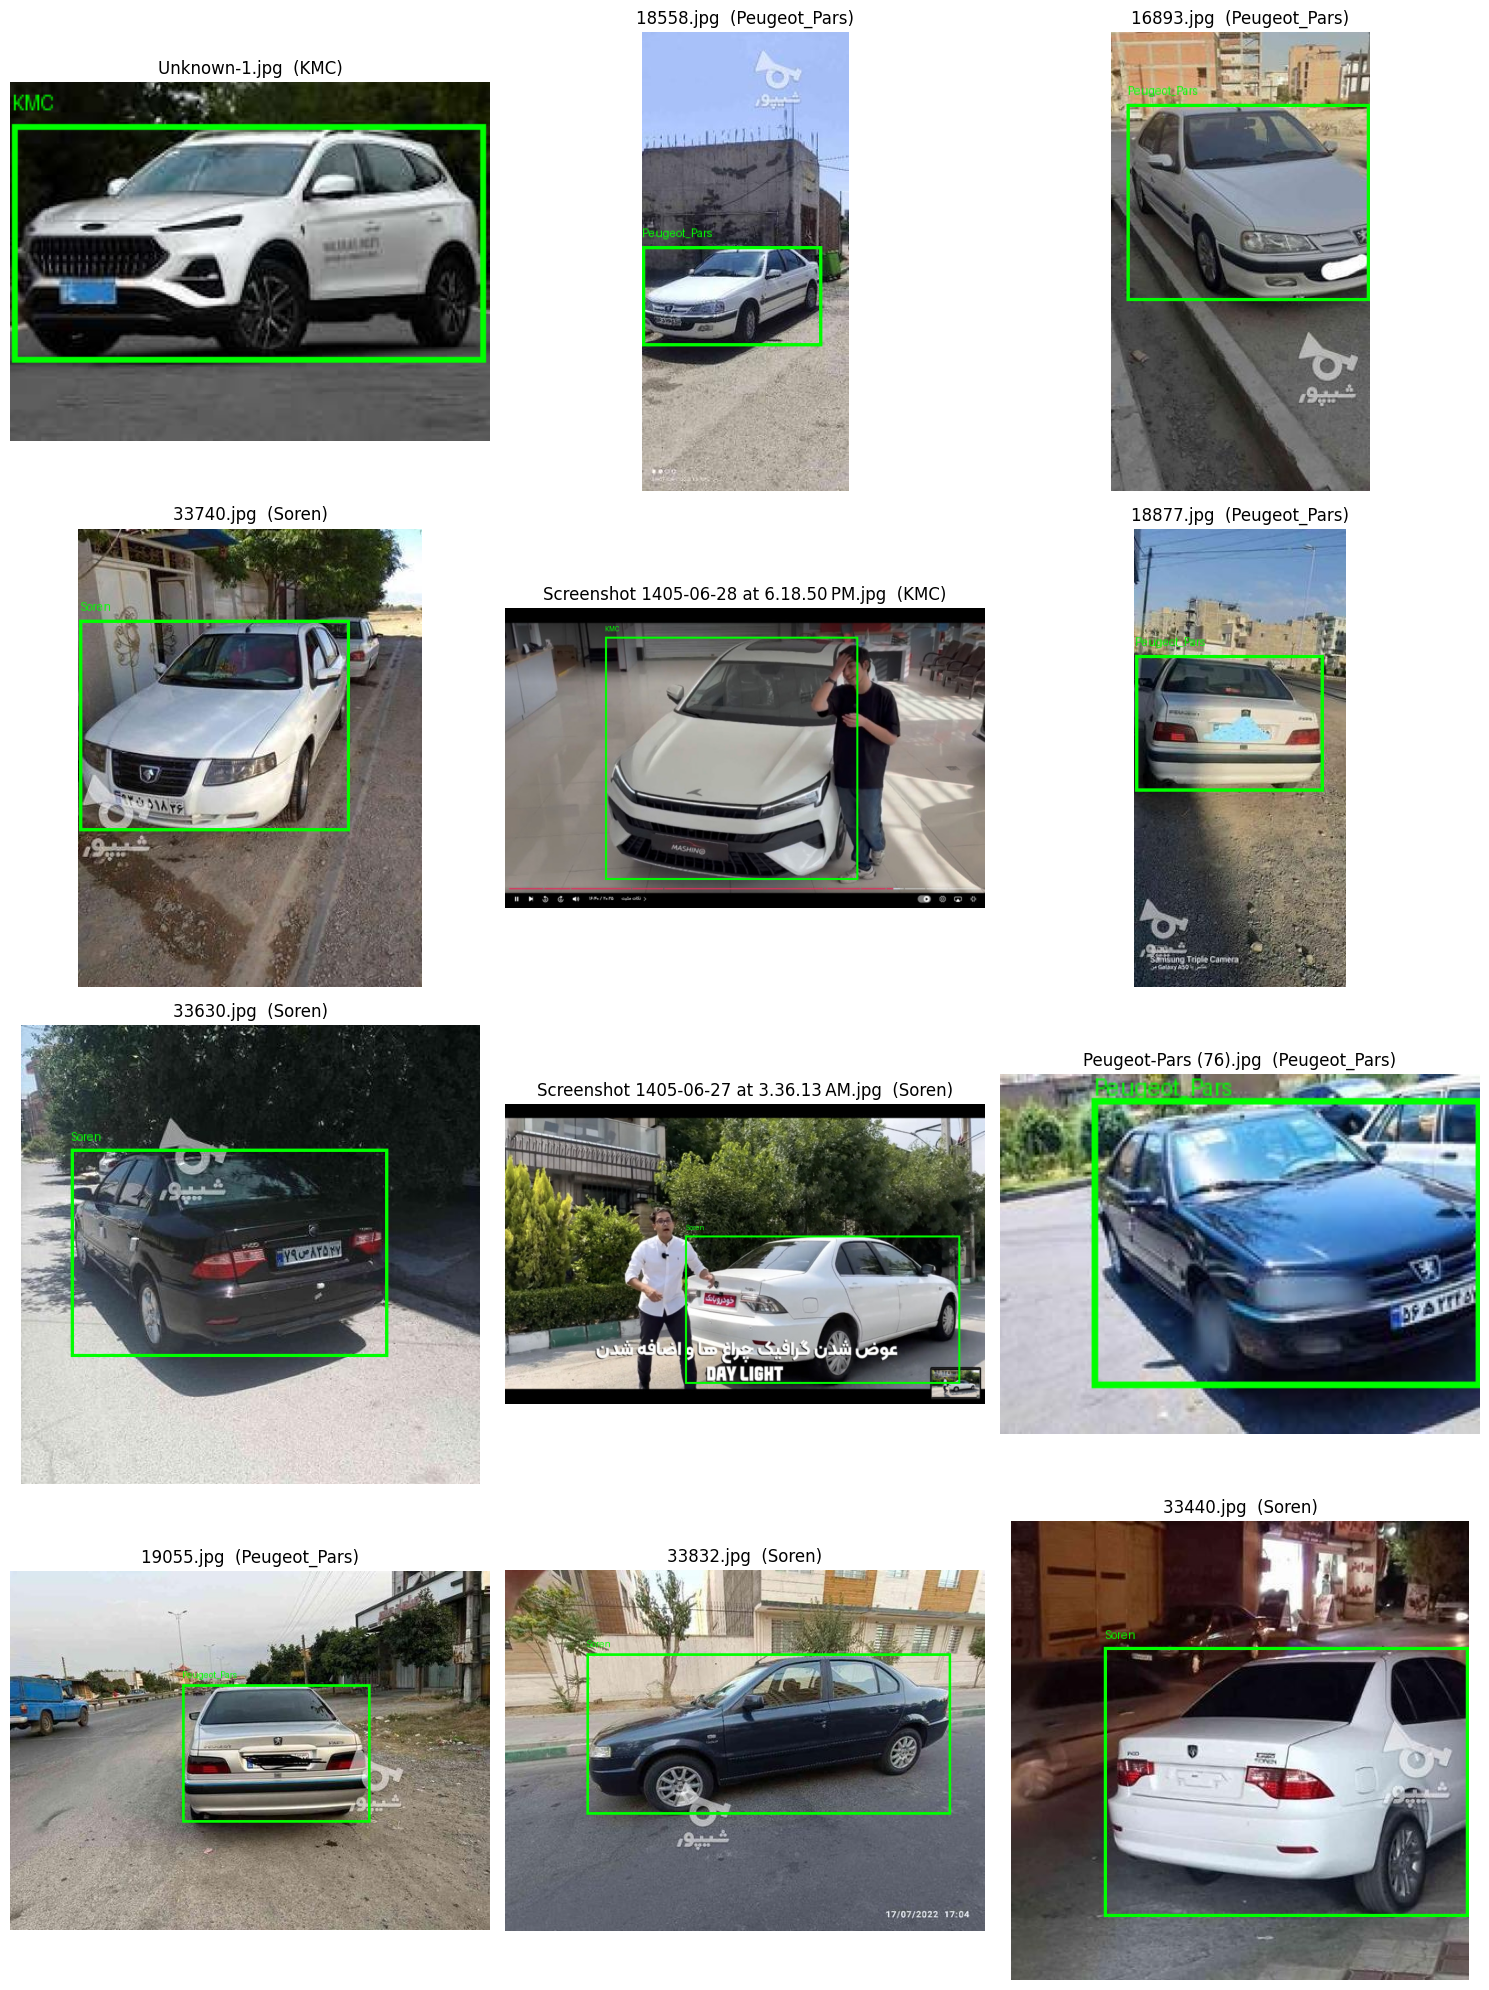

Previews also saved to /content/auto_labels/previews


In [7]:
import random
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def draw_yolo_box(img_path, label_path, class_names):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    draw = ImageDraw.Draw(img)
    if label_path.exists() and label_path.stat().st_size > 0:
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cid, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
            x1 = (xc - bw/2) * w
            y1 = (yc - bh/2) * h
            x2 = (xc + bw/2) * w
            y2 = (yc + bh/2) * h
            draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)
            label = class_names[cid] if cid < len(class_names) else str(cid)
            draw.text((x1, max(0, y1-18)), label, fill="lime")
    return img

# Pick random successful samples (labels now live in class subfolders)
labeled_samples = []
for p, cid, cname in samples:
    lbl = labels_dir / cname / f"{p.stem}.txt"
    if lbl.exists() and lbl.stat().st_size > 0:
        labeled_samples.append((p, cid, cname))

preview = random.sample(labeled_samples, min(NUM_PREVIEW, len(labeled_samples)))

cols = 3
rows = (len(preview) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

for ax, (img_path, cid, cname) in zip(axes, preview):
    lbl = labels_dir / cname / f"{img_path.stem}.txt"
    vis = draw_yolo_box(img_path, lbl, CLASS_NAMES)
    ax.imshow(vis)
    ax.set_title(f"{img_path.name}  ({cname})")
    ax.axis("off")
    # also save individual preview
    vis.save(preview_dir / f"{img_path.stem}_preview.jpg")

for ax in axes[len(preview):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Previews also saved to {preview_dir}")


## 8. Create dataset.yaml + copy images (optional but recommended)

In [8]:
import shutil

# Create a clean YOLO dataset that preserves class folders
# Structure:
#   yolo_dataset/
#     images/
#       sedan/...
#       suv/...
#     labels/
#       sedan/...
#       suv/...
#     dataset.yaml

ds_root = OUTPUT_DIR / "yolo_dataset"
img_out = ds_root / "images"
lbl_out = ds_root / "labels"
img_out.mkdir(parents=True, exist_ok=True)
lbl_out.mkdir(parents=True, exist_ok=True)

for img_path, class_id, class_name in tqdm(samples, desc="Building dataset"):
    lbl_src = labels_dir / class_name / f"{img_path.stem}.txt"
    if not lbl_src.exists():
        continue

    # image → images/<class_name>/
    class_img_dir = img_out / class_name
    class_img_dir.mkdir(parents=True, exist_ok=True)
    dst_img = class_img_dir / img_path.name
    if not dst_img.exists():
        shutil.copy2(img_path, dst_img)

    # label → labels/<class_name>/
    class_lbl_dir = lbl_out / class_name
    class_lbl_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(lbl_src, class_lbl_dir / f"{img_path.stem}.txt")

# dataset.yaml – YOLO will recurse into subfolders automatically
yaml_content = {
    "path": str(ds_root.resolve()),
    "train": "images",          # will find images in images/**
    "val": "images",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
    "nc": len(CLASS_NAMES),
}
yaml_path = ds_root / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"YOLO dataset ready at: {ds_root}")
print(f"dataset.yaml          : {yaml_path}")
print("Structure:")
for split in ["images", "labels"]:
    root = ds_root / split
    if root.exists():
        for d in sorted(root.iterdir()):
            if d.is_dir():
                n = len(list(d.glob("*")))
                print(f"  {split}/{d.name}: {n} files")


Building dataset:   0%|          | 0/1724 [00:00<?, ?it/s]

YOLO dataset ready at: /content/auto_labels/yolo_dataset
dataset.yaml          : /content/auto_labels/yolo_dataset/dataset.yaml
Structure:
  images/KMC: 480 files
  images/Peugeot_Pars: 624 files
  images/Soren: 620 files
  labels/KMC: 480 files
  labels/Peugeot_Pars: 624 files
  labels/Soren: 620 files


## 9. Zip everything for easy download

In [9]:
import zipfile

zip_path = OUTPUT_DIR / "car_auto_labels.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    # labels (with class subfolders)
    for f in labels_dir.rglob("*.txt"):
        zf.write(f, f.relative_to(OUTPUT_DIR))
    # full dataset (images + labels + yaml)
    for f in (OUTPUT_DIR / "yolo_dataset").rglob("*"):
        if f.is_file():
            zf.write(f, f.relative_to(OUTPUT_DIR))
    # previews
    for f in preview_dir.glob("*"):
        zf.write(f, f"previews/{f.name}")

print(f"Archive created: {zip_path}")
print(f"Size: {zip_path.stat().st_size / 1024**2:.1f} MB")

# Colab download helper
try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    print("Not in Colab – download the zip manually from the output folder.")


Archive created: /content/auto_labels/car_auto_labels.zip
Size: 105.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Tips for even higher accuracy / troubleshooting

| Issue | Fix |
|-------|-----|
| Many “no car” | Lower `CONF_THRES` to 0.15, raise `IMGSZ` (e.g. 1536) if VRAM allows, or try multi-scale `IMGSZ = [960, 1280]` |
| Boxes slightly loose/tight | COCO-pretrained model is already strong; short fine-tune later helps domain-specific cars |
| Multiple cars per image | Current code keeps the **highest-confidence** box. Edit the loop to write *all* car boxes if needed |
| VRAM OOM on T4 | Lower `IMGSZ` (e.g. 960), set `AUGMENT=False`, or use single-scale |
| Variable image sizes | Already supported – YOLO letterboxes every image. Check size stats cell for a suggested `IMGSZ` |
| Want oriented boxes (OBB) | Swap to `yolo26x-obb.pt` and adjust the label writer |
| Class folders have different names | Just edit `CLASS_NAMES` list – order = class_id |

**Multi-scale example** (higher accuracy, slower):
```python
IMGSZ = [960, 1280]   # or [640, 960, 1280]
```

**Next step after labeling**:  
Split `yolo_dataset` into train/val (e.g. 80/20), then fine-tune:
```python
model = YOLO("yolo26x.pt")
model.train(data="path/to/dataset.yaml", epochs=50, imgsz=1280, batch=4)
```

Happy labeling!
